---
title: "Health Expectancy"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Health Expenditure and Life Expectancy
- **description:** Annual per-capita health-care spending paired with life expectancy at birth for six wealthy nations, 1970–2020.
- **provenance:** Our World in Data, combining OECD health-expenditure statistics (per-capita spending) with UN World Population Prospects (life expectancy), 1970–2020.
- **format:** long / tidy — 274 rows x 4 columns.

**Data dictionary**

- `Year` — *(identifier)* calendar year of the observation.
- `Country` — *(identifier)* one of six countries: Canada, France, Germany, Great Britain, Japan, USA.
- `Spending_USD` — *(measurement)* health-care spending per capita, in US dollars.
- `Life_Expectancy` — *(measurement)* life expectancy at birth, in years.

**Structure**

- **Rows:** 274 — one row per country-year (coverage varies by country).
- **Columns:** 4.
- **Identifiers:** `Year`, `Country`.
- **Measurements:** `Spending_USD`, `Life_Expectancy`.

**Use cases**

- scatter plots of spending vs. life expectancy, colored by country
- per-country trend lines over time
- bar charts comparing budgets or outcomes across countries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

Since the data are already aggregated by Year and Country, this may not technically fall under the category of tidy.

In [2]:
healthexp = sns.load_dataset('healthexp')
healthexp

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


### Long form with key index

We separate out identity data from measurements.

In [3]:
healthexp1 = healthexp.set_index(['Year', 'Country'])
healthexp1

Spending_USD  Life_Expectancy
Year Country                                     
1970 Germany             252.311             70.6
     France              192.143             72.2
     Great Britain       123.993             71.9
     Japan               150.437             72.0
     USA                 326.961             70.9
...                          ...              ...
2020 Germany            6938.983             81.1
     France             5468.418             82.3
     Great Britain      5018.700             80.4
     Japan              4665.641             84.7
     USA               11859.179             77.0

[274 rows x 2 columns]

### Long form aggregated by Country

We drop out Year and get the mean values of each measurement.

In [4]:
healthexp2 = healthexp.groupby(['Country']).agg({'Life_Expectancy':'mean', 'Spending_USD':'sum'})
healthexp2

,Life_Expectancy,Spending_USD
Country,,
Canada,78.706818,118174.247
France,79.565714,106580.077
Germany,76.726000,133364.010
Great Britain,77.620930,87470.276
Japan,79.554902,94873.153
USA,75.843137,223817.097


### Long form aggregated by Year

We drop out Country and get the mean values of each measurement.

In [5]:
healthexp3 = healthexp.groupby(['Year']).agg({'Life_Expectancy':'mean', 'Spending_USD':'sum'})
healthexp3

,Life_Expectancy,Spending_USD
Year,,
1970,71.520000,1045.845
1971,71.920000,1267.656
1972,71.800000,919.851
1973,72.033333,1029.621
1974,72.400000,1189.876
1975,72.850000,1741.110
1976,73.325000,2077.011
1977,73.700000,1714.221
1978,73.866667,1930.918


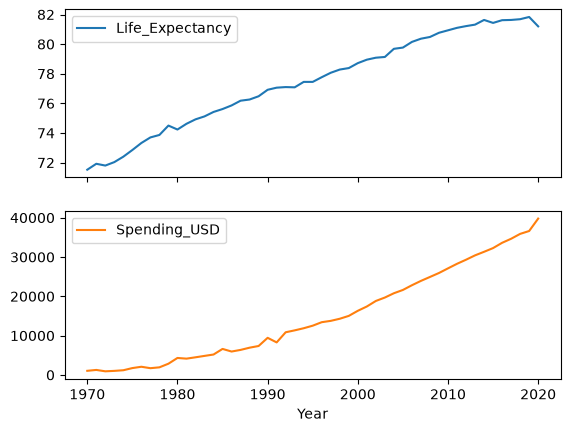

In [6]:
healthexp3.plot(subplots=True)
plt.show()

### Long form of Spending_USD

We represent the data for one measurement by projecting one index into column space.

In [7]:
healthexp3 = healthexp1.Spending_USD.unstack()
healthexp3

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,192.143,252.311,123.993,150.437,326.961
1971,313.391,NaN,298.251,134.172,163.854,357.988
1972,NaN,NaN,337.364,NaN,185.390,397.097
1973,NaN,NaN,384.541,NaN,205.778,439.302
1974,NaN,NaN,452.744,NaN,242.018,495.114
1975,NaN,363.610,532.481,NaN,284.269,560.750
1976,543.337,NaN,591.098,NaN,303.725,638.851
1977,NaN,NaN,647.352,NaN,340.628,726.241
1978,NaN,NaN,729.457,NaN,392.577,808.884


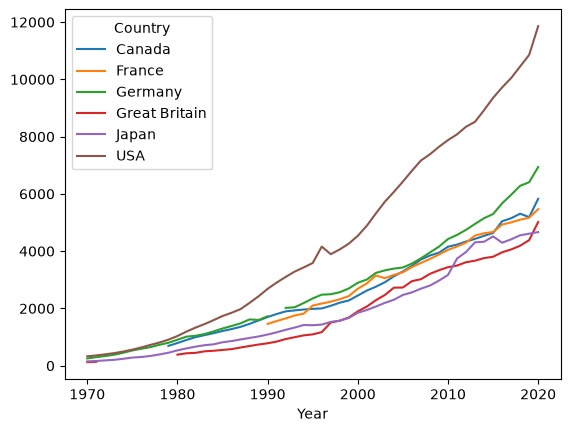

In [8]:
healthexp3.plot()
plt.show()

### Long form of Life_Expectancy

We represent the data for the other measurement by projecting one index into column space.

In [9]:
healthexp4 = healthexp1.Life_Expectancy.unstack()
healthexp4 

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0
1975,NaN,73.0,71.4,NaN,74.3,72.7
1976,73.8,NaN,71.8,NaN,74.8,72.9
1977,NaN,NaN,72.5,NaN,75.3,73.3
1978,NaN,NaN,72.4,NaN,75.7,73.5


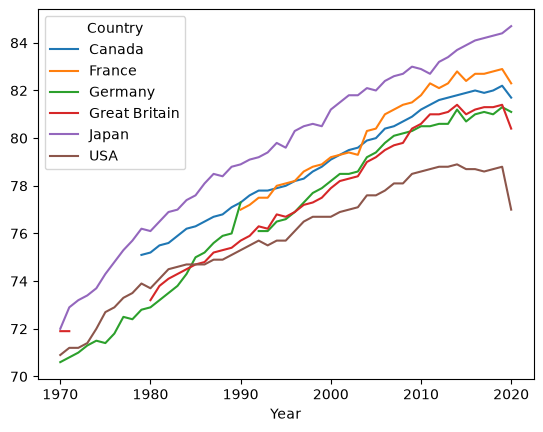

In [10]:
healthexp4.plot()
plt.show()

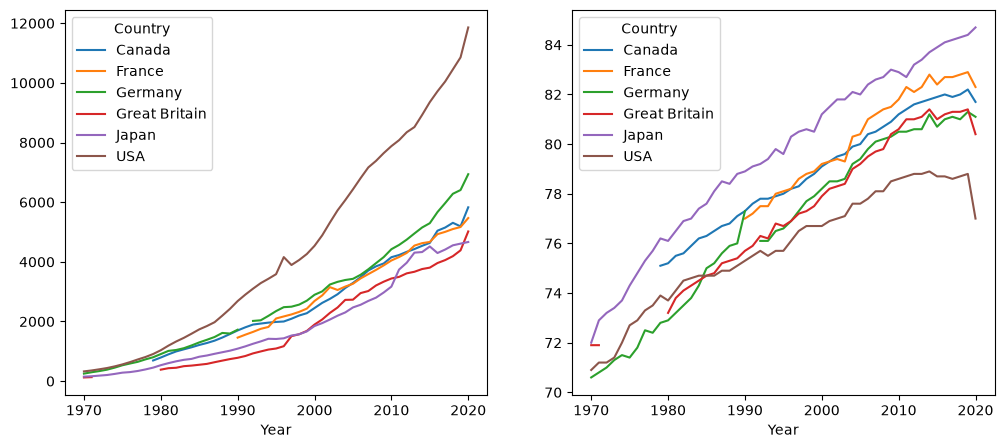

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
healthexp3.plot(ax=ax[0])
healthexp4.plot(ax=ax[1])
plt.show()

### Aggregation with wide form data

Note the wide form representations of a single measure in the space of two nominal identifiers allows for quick aggregation.

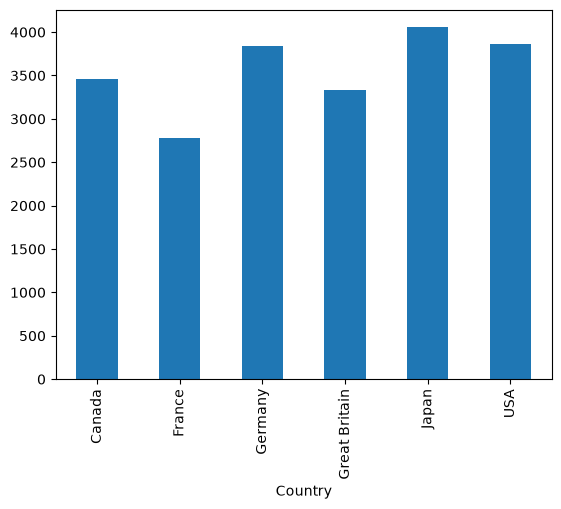

In [12]:
healthexp4.sum().plot.bar()
plt.show()

In [13]:
healthexp4.sum(axis=1)

Year
1970    357.6
1971    359.6
1972    215.4
1973    216.1
1974    217.2
1975    291.4
1976    293.3
1977    221.1
1978    221.6
1979    298.0
1980    445.4
1981    373.1
1982    374.6
1983    375.6
1984    377.1
1985    453.7
1986    379.3
1987    380.9
1988    381.3
1989    382.4
1990    461.5
1991    385.3
1992    462.6
1993    462.5
1994    464.7
1995    464.7
1996    466.6
1997    468.4
1998    469.7
1999    470.3
2000    472.3
2001    473.7
2002    474.5
2003    474.8
2004    478.1
2005    478.6
2006    480.9
2007    482.2
2008    482.9
2009    484.6
2010    485.6
2011    486.6
2012    487.3
2013    487.9
2014    489.8
2015    488.6
2016    489.7
2017    489.8
2018    490.1
2019    491.0
2020    487.2
dtype: float64